In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load the cleaned phishing dataset
df = pd.read_csv("../data/cleaned/phishing_cleaned.csv")

# Check the dataset dimensions
df.shape

(235795, 55)

In [2]:
# Raw text columns will not be used directly by our tabular ML models
columns_to_remove = [
    "URL",
    "Domain",
    "TLD",
    "Title"
]

# Define X and y
X = df.drop(columns=columns_to_remove + ["label"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235795, 50)
y shape: (235795,)


In [3]:

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [4]:
# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import preprocessing and pipeline tools
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Store model performance so we can compare all models later
model_results = []


def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a classification model using several performance metrics
    and display its confusion matrix.
    """

    # Generate class predictions
    y_pred = model.predict(X_test)

    # Generate phishing probabilities 
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Save results for later comparison
    model_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

    # Display all model metrics
    print(f"{name} Results")
    print("-" * 40)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Phishing"],
        yticklabels=["Legitimate", "Phishing"]
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

Logistic Regression Results
----------------------------------------
Accuracy:  0.9999
Precision: 1.0000
Recall:    0.9998
F1 Score:  0.9999
ROC-AUC:   1.0000


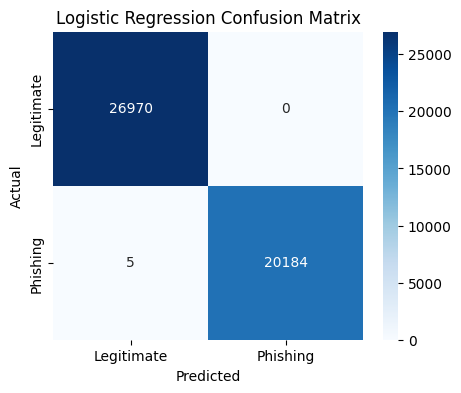

In [6]:
# Logistic Regression pipeline
# Scaling is performed using only the training data inside the pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

Decision Tree Results
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000


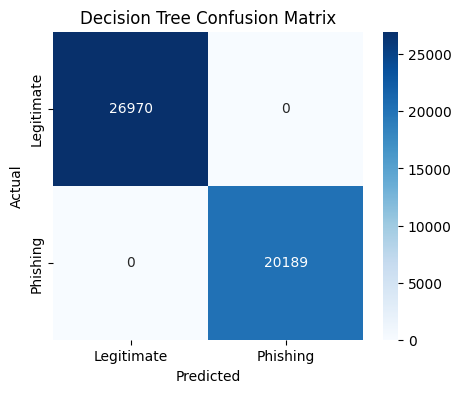

In [ ]:
# Decision Tree classifier
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)

Random Forest Results
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000


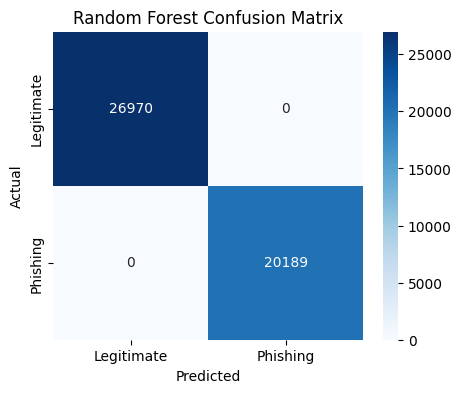

In [8]:
# Random Forest classifier
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

XGBoost Results
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000


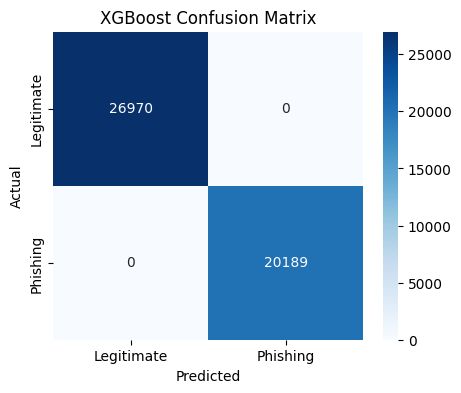

In [9]:
# XGBoost classifier
xgboost_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgboost_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(
    "XGBoost",
    xgboost_model,
    X_test,
    y_test
)

In [10]:
# Convert the stored model results into a DataFrame
results_df = pd.DataFrame(model_results)

# Sort by phishing recall because missing phishing websites is especially important for this classification problem
results_df = results_df.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,1.000000,1.0,1.000000,1.000000,1.0
1,Random Forest,1.000000,1.0,1.000000,1.000000,1.0
2,XGBoost,1.000000,1.0,1.000000,1.000000,1.0
3,Logistic Regression,0.999894,1.0,0.999752,0.999876,1.0


### Key Findings — Full-Feature Models

- All four models achieved exceptionally strong performance, with accuracy above 99.98%.
- Decision Tree, Random Forest, and XGBoost achieved 100% accuracy, precision, recall, F1, and ROC-AUC** on the test set.
- Logistic Regression also performed extremely well, reaching 99.98% accuracy and 99.98% phishing recall.
- The nonlinear tree-based models slightly outperformed Logistic Regression, suggesting that interactions between website characteristics help distinguish phishing from legitimate websites.
- The near-perfect results suggest that the engineered PhiUSIIL features provide extremely strong class separation. Because performance is unusually high, the next experiment will test a reduced feature set to determine whether similar performance can be maintained with fewer predictors.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [13]:
# Create 5 stratified folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate the same metrics used during test-set evaluation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [18]:
# Perform 5-fold cross-validation on the Random Forest
rf_cv = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Display the mean and standard deviation across the five folds
print("Random Forest Cross-Validation Results")

for metric in scoring:
    scores = rf_cv[f"test_{metric}"]

    print(
        f"{metric:10}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Random Forest Cross-Validation Results
accuracy  : 1.0000 ± 0.0000
precision : 1.0000 ± 0.0000
recall    : 1.0000 ± 0.0000
f1        : 1.0000 ± 0.0000
roc_auc   : 1.0000 ± 0.0000


In [19]:
# Perform 5-fold cross-validation on XGBoost
xgb_cv = cross_validate(
    xgboost_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Display the mean and standard deviation across the five folds
print("XGBoost Cross-Validation Results")

for metric in scoring:
    scores = xgb_cv[f"test_{metric}"]

    print(
        f"{metric:10}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

XGBoost Cross-Validation Results
accuracy  : 1.0000 ± 0.0000
precision : 1.0000 ± 0.0000
recall    : 1.0000 ± 0.0001
f1        : 1.0000 ± 0.0000
roc_auc   : 1.0000 ± 0.0000


### Key Finding

- Random Forest achieved perfect 5-fold cross-validation scores across all metrics, with essentially no variation between folds.
- XGBoost also performed nearly perfectly, with only a very small amount of variation in recall and F1-score.
- The consistency across multiple folds suggests that the strong model performance is not dependent on a single train/test split.
- However, because performance is unusually high, potential data leakage or highly predictive features should still be considered before final model selection.

In [20]:
# Get feature importance scores from the trained Random Forest model
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from most to least important
rf_importance = (
    rf_importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

rf_importance

,Feature,Importance
3,URLSimilarityIndex,0.177997
49,NoOfExternalRef,0.165502
22,LineOfCode,0.154833
47,NoOfSelfRef,0.105177
44,NoOfImage,0.083229
46,NoOfJS,0.070344
45,NoOfCSS,0.032453
36,HasSocialNet,0.032015
43,HasCopyrightInfo,0.026685
21,IsHTTPS,0.023774


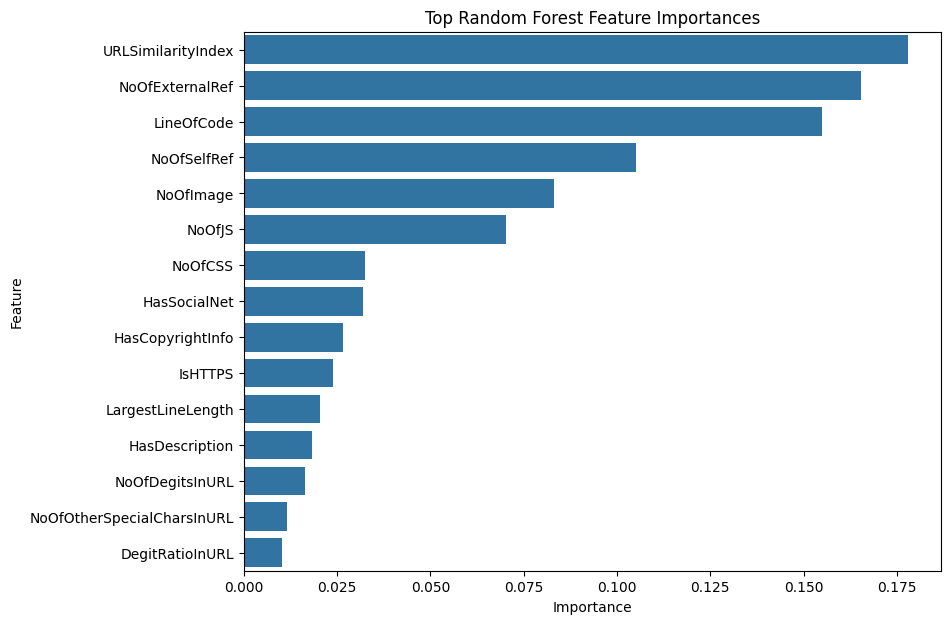

In [21]:
# Visualize the 15 most important Random Forest features
plt.figure(figsize=(9, 7))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [22]:
# Get feature importance scores from the trained XGBoost model
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgboost_model.feature_importances_
})

# Sort features from most to least important
xgb_importance = (
    xgb_importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

xgb_importance

,Feature,Importance
3,URLSimilarityIndex,0.981442
22,LineOfCode,0.015567
21,IsHTTPS,0.002160
47,NoOfSelfRef,0.000202
49,NoOfExternalRef,0.000133
36,HasSocialNet,0.000119
23,LargestLineLength,0.000081
44,NoOfImage,0.000071
46,NoOfJS,0.000056
13,LetterRatioInURL,0.000043


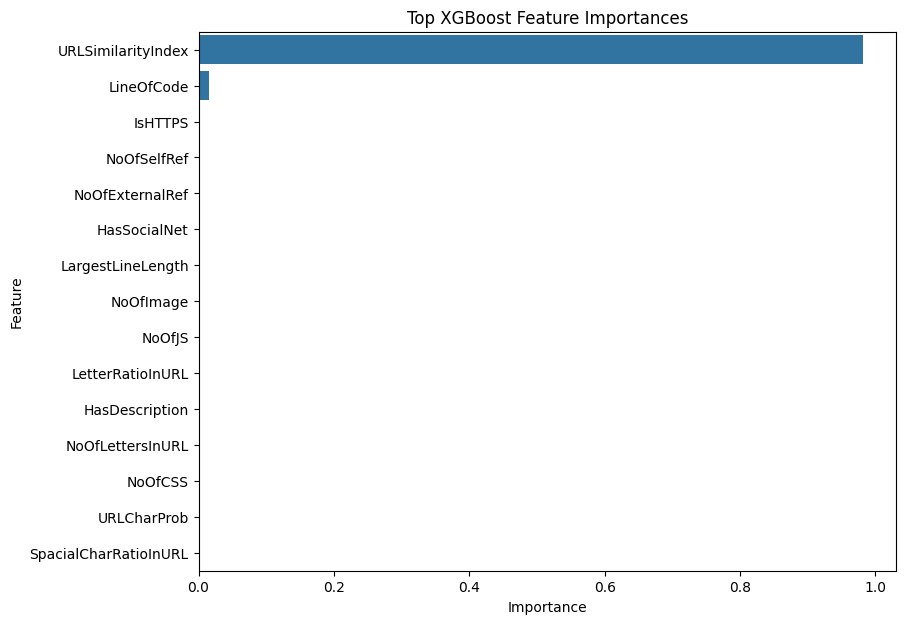

In [24]:
# Visualize the 15 most important XGBoost features
plt.figure(figsize=(9, 7))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [27]:
# Extract Logistic Regression model from the pipeline
log_reg = logistic_model.named_steps["model"]

# Extract coefficients
log_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
})

# Calculate absolute coefficient size for ranking
log_coefficients["Absolute Coefficient"] = (
    log_coefficients["Coefficient"].abs()
)

# Select the 15 strongest coefficients
log_top_coefficients = (
    log_coefficients
    .sort_values("Absolute Coefficient", ascending=False)
    .head(15)
)

log_top_coefficients

,Feature,Coefficient,Absolute Coefficient
3,URLSimilarityIndex,-6.956245,6.956245
21,IsHTTPS,-3.879599,3.879599
20,SpacialCharRatioInURL,1.887845,1.887845
13,LetterRatioInURL,1.774712,1.774712
46,NoOfJS,-1.770485,1.770485
36,HasSocialNet,-1.478811,1.478811
47,NoOfSelfRef,-1.383850,1.383850
44,NoOfImage,-1.261538,1.261538
8,NoOfSubDomain,-1.259081,1.259081
15,DegitRatioInURL,1.233362,1.233362


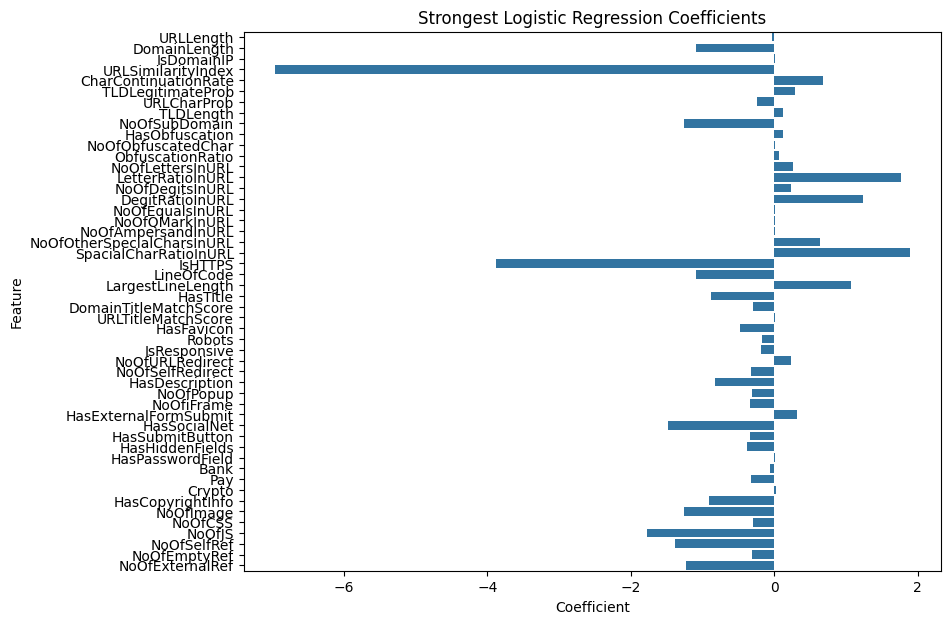

In [28]:
# Visualize the strongest Logistic Regression coefficients
plt.figure(figsize=(9, 7))

sns.barplot(
    data=log_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Strongest Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Key Finding

- `URLSimilarityIndex` is the standout feature across all three models and is especially dominant in XGBoost, accounting for about 98% of its feature importance.
- Random Forest spreads importance more broadly across features such as `NoOfExternalRef`, `LineOfCode`, `NoOfSelfRef`, and `NoOfImage`, although `URLSimilarityIndex` is still the strongest individual predictor.
- Logistic Regression also identifies `URLSimilarityIndex` as its strongest coefficient by a large margin, with `IsHTTPS` another notable predictor.
- The agreement across models suggests that the near-perfect performance is heavily influenced by a small number of highly predictive features rather than all website characteristics contributing equally.
- Should create reduced-feature experiment to test whether strong phishing detection remains possible without the most dominant signals.

In [29]:
# Select a smaller set of practical and interpretable website features
# Highly dominant similarity/probability features are intentionally excluded
reduced_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "IsHTTPS",
    "NoOfSubDomain",
    "NoOfURLRedirect",
    "NoOfExternalRef",
    "HasPasswordField",
    "HasHiddenFields",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasCopyrightInfo",
    "Bank",
    "Pay",
    "Crypto"
]

# Create reduced predictor dataset
X_reduced = df[reduced_features]

# Target remains unchanged
y_reduced = df["label"]

X_reduced.shape

(235795, 15)

In [30]:
# Create an 80/20 train-test split using the reduced feature set
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.20,
    stratify=y_reduced,
    random_state=42
)

In [31]:
# Logistic Regression requires feature scaling
reduced_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Decision Tree
reduced_dt_model = DecisionTreeClassifier(
    random_state=42
)

# Random Forest
reduced_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# XGBoost
reduced_xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Store models together for consistent evaluation
reduced_models = {
    "Logistic Regression": reduced_logistic_model,
    "Decision Tree": reduced_dt_model,
    "Random Forest": reduced_rf_model,
    "XGBoost": reduced_xgb_model
}

In [32]:
# Store evaluation results for each reduced-feature model
reduced_results = []

for name, model in reduced_models.items():

    # Train model
    model.fit(X_train_reduced, y_train_reduced)

    # Generate class predictions
    y_pred = model.predict(X_test_reduced)

    # Generate probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test_reduced)[:, 1]

    # Calculate evaluation metrics
    reduced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_reduced, y_pred),
        "Precision": precision_score(y_test_reduced, y_pred),
        "Recall": recall_score(y_test_reduced, y_pred),
        "F1": f1_score(y_test_reduced, y_pred),
        "ROC-AUC": roc_auc_score(y_test_reduced, y_prob)
    })

# Convert results into a DataFrame
reduced_results_df = pd.DataFrame(reduced_results)

# Sort by phishing recall
reduced_results_df = (
    reduced_results_df
    .sort_values("Recall", ascending=False)
    .reset_index(drop=True)
)

reduced_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.998813,0.998613,0.998613,0.998613,0.999978
1,Decision Tree,0.997858,0.997671,0.997325,0.997498,0.998231
2,Random Forest,0.997625,0.997571,0.996879,0.997225,0.999871
3,Logistic Regression,0.993236,0.989457,0.994799,0.992121,0.999736


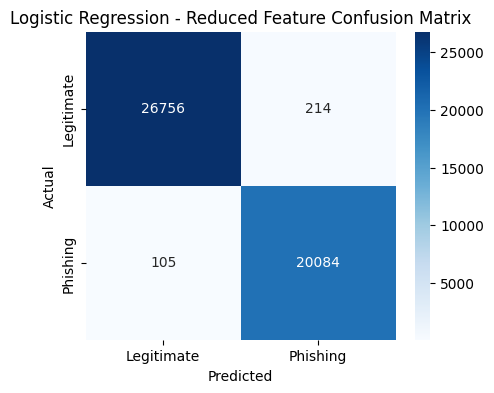

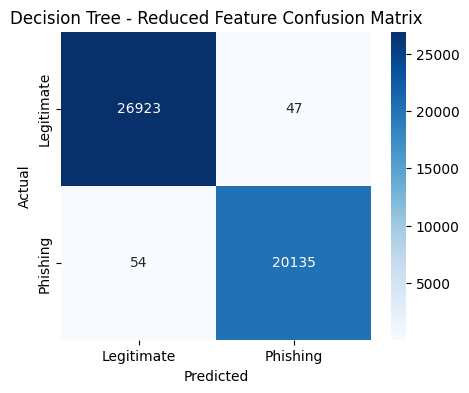

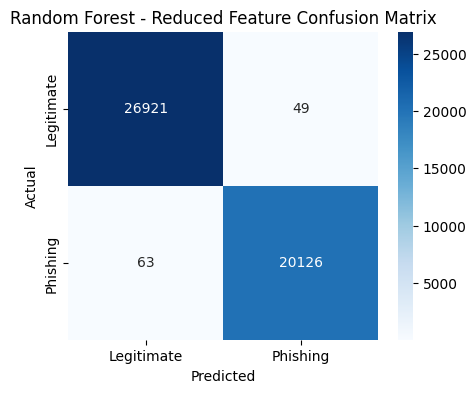

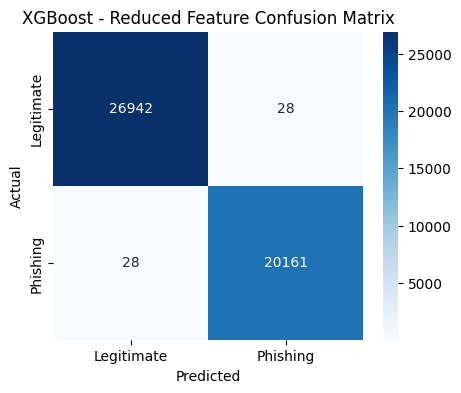

In [33]:
# Display confusion matrix for each reduced-feature model
for name, model in reduced_models.items():

    y_pred = model.predict(X_test_reduced)

    cm = confusion_matrix(y_test_reduced, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Phishing"],
        yticklabels=["Legitimate", "Phishing"]
    )

    plt.title(f"{name} - Reduced Feature Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [34]:
# Compare full-feature and reduced-feature model performance
comparison_df = results_df[["Model", "F1", "Recall"]].merge(
    reduced_results_df[["Model", "F1", "Recall"]],
    on="Model",
    suffixes=("_Full", "_Reduced")
)

# Rename columns for readability
comparison_df.columns = [
    "Model",
    "Full F1",
    "Full Recall",
    "Reduced F1",
    "Reduced Recall"
]

comparison_df

,Model,Full F1,Full Recall,Reduced F1,Reduced Recall
0,Decision Tree,1.000000,1.000000,0.997498,0.997325
1,Random Forest,1.000000,1.000000,0.997225,0.996879
2,XGBoost,1.000000,1.000000,0.998613,0.998613
3,Logistic Regression,0.999876,0.999752,0.992121,0.994799


### Key Finding — Reduced-Feature Models

- All four models maintained very strong performance using only 15 selected features, showing that phishing websites can still be identified accurately without the strongest engineered predictors.
- XGBoost performed best, achieving approximately 99.88% accuracy, 99.86% precision, 99.86% recall, and 99.86% F1-score**.
- XGBoost produced only 28 false negatives**, meaning just 28 phishing websites in the test set were incorrectly classified as legitimate.
- Random Forest and Decision Tree also exceeded 99.7% accuracy**, while Logistic Regression remained strong at approximately 99.32% accuracy**.
- The small performance decline compared with the full-feature models suggests that features such as `URLSimilarityIndex` contributed heavily to the near-perfect original results, but were not necessary for strong phishing detection**.
- - This shows that strong phishing detection can be achieved without relying on the full feature set or a few dominant predictors.

In [35]:
## FINAL MODEL AND ERROR ANALYSIS
# Use reduced-feature XGBoost as the final model
final_model = reduced_models["XGBoost"]

# Make predictions on the test data
y_pred = final_model.predict(X_test_reduced)

# Get predicted phishing probabilities
y_proba = final_model.predict_proba(X_test_reduced)[:, 1]

In [36]:
# Create a DataFrame containing the model's predictions
final_results = pd.DataFrame({
    "Actual": y_test_reduced.values,
    "Predicted": y_pred,
    "Phishing_Probability": y_proba
}, index=X_test_reduced.index)

final_results.head()

,Actual,Predicted,Phishing_Probability
130287,0,0,0.000007
67439,1,1,0.999988
34963,0,0,0.000076
30759,1,1,0.999997
206263,0,0,0.000016


In [38]:
# Label each prediction as TP, TN, FP, or FN
conditions = [
    (final_results["Actual"] == 1) & (final_results["Predicted"] == 1),
    (final_results["Actual"] == 0) & (final_results["Predicted"] == 0),
    (final_results["Actual"] == 0) & (final_results["Predicted"] == 1),
    (final_results["Actual"] == 1) & (final_results["Predicted"] == 0)
]

labels = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

final_results["Prediction_Result"] = np.select(
    conditions,
    labels,
    default="Unknown"
)

# Count each prediction result
final_results["Prediction_Result"].value_counts()

Prediction_Result
True Negative     26942
True Positive     20161
False Negative       28
False Positive       28
Name: count, dtype: int64

In [43]:

# Separate the model's two types of errors
false_negatives = final_results[
    final_results["Prediction_Result"] == "False Negative"
]

false_positives = final_results[
    final_results["Prediction_Result"] == "False Positive"

]

print("False Negatives:", len(false_negatives))
print("False Positives:", len(false_positives))

False Negatives: 28
False Positives: 28


In [44]:
# Average characteristics of phishing websites the model missed
false_negatives[X_test_reduced.columns].mean().sort_values(
    ascending=False
)

URLLength                29.035714
DomainLength             21.571429
NoOfExternalRef           7.071429
NoOfSubDomain             1.142857
IsHTTPS                   1.000000
HasHiddenFields           0.285714
HasCopyrightInfo          0.285714
HasSocialNet              0.250000
NoOfURLRedirect           0.178571
Pay                       0.142857
Bank                      0.107143
Crypto                    0.071429
HasPasswordField          0.035714
HasExternalFormSubmit     0.035714
IsDomainIP                0.000000
dtype: float64

In [45]:
# Average characteristics of legitimate websites incorrectly flagged as phishing
false_positives[X_test_reduced.columns].mean().sort_values(
    ascending=False
)

URLLength                29.785714
DomainLength             22.785714
NoOfExternalRef           1.392857
NoOfSubDomain             1.214286
IsHTTPS                   1.000000
HasHiddenFields           0.107143
Pay                       0.071429
NoOfURLRedirect           0.035714
HasPasswordField          0.035714
HasCopyrightInfo          0.035714
Bank                      0.035714
IsDomainIP                0.000000
HasExternalFormSubmit     0.000000
HasSocialNet              0.000000
Crypto                    0.000000
dtype: float64

### Key Finding — Error Analysis

- The final XGBoost model made only 28 false negatives and 28 false positives**, showing very few classification errors overall.
- Missed phishing websites tended to have relatively moderate URL and domain lengths and all used HTTPS**, making them appear more similar to legitimate websites.
- False positives showed similar URL/domain characteristics, suggesting these borderline cases share characteristics across both classes.
- Overall, the remaining errors appear to involve websites with less obvious phishing signals rather than extreme suspicious characteristics.

In [46]:
# Get full-model F1 scores
full_metrics = results_df[
    ["Model", "F1"]
].copy()

full_metrics = full_metrics.rename(columns={
    "F1": "Full_F1"
})


# Get reduced-model metrics
reduced_metrics = reduced_results_df[
    ["Model", "Precision", "Recall", "F1", "ROC-AUC"]
].copy()

reduced_metrics = reduced_metrics.rename(columns={
    "Precision": "Reduced_Precision",
    "Recall": "Reduced_Recall",
    "F1": "Reduced_F1",
    "ROC-AUC": "Reduced_ROC_AUC"
})


# Combine the results
model_performance = full_metrics.merge(
    reduced_metrics,
    on="Model"
)

model_performance

,Model,Full_F1,Reduced_Precision,Reduced_Recall,Reduced_F1,Reduced_ROC_AUC
0,Decision Tree,1.000000,0.997671,0.997325,0.997498,0.998231
1,Random Forest,1.000000,0.997571,0.996879,0.997225,0.999871
2,XGBoost,1.000000,0.998613,0.998613,0.998613,0.999978
3,Logistic Regression,0.999876,0.989457,0.994799,0.992121,0.999736


In [47]:
# Save for Tableau
model_performance.to_csv(
    "../data/model_outputs/model_performance.csv",
    index=False
)